<a href="https://colab.research.google.com/github/SalvarezJ/Crib-Sentry/blob/main/notebooks/09_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crib Sentry: Demo
In this demonstration I run the system on six images. The first four show one correct alert of each type and the last two show failures. Cyan is the crib box, blue is the child box and red is a hazard box.

In [ ]:
!pip install -q ultralytics roboflow

from google.colab import drive, userdata
drive.mount('/content/drive')

import glob, os, time
from ultralytics import YOLO
from roboflow import Roboflow
from PIL import Image as PILImage, ImageDraw, ImageFont
from IPython.display import Image, display

base = '/content/drive/MyDrive/crib_sentry_v2'
crib_model = YOLO(f'{base}/crib/weights/best.pt')
child_model = YOLO(f'{base}/child-2/weights/best.pt')
hazard_model = YOLO(f'{base}/hazards/weights/best.pt')

rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))
dataset = rf.workspace("test-1caua").project("baby-in-crib").version(1).download("yolov11")
test_images = sorted(glob.glob(dataset.location + '/test/images/*'))
!mkdir -p /content/left && cp {base}/left_the_crib_test/* /content/left/
left_images = sorted(glob.glob('/content/left/*'))

for model in [crib_model, child_model, hazard_model]:
    model(test_images[0], verbose=False)   # the first call loads the model on the GPU
os.makedirs(f'{base}/results', exist_ok=True)
print('Ready:', len(test_images), 'test images,', len(left_images), 'left the crib images')

In [ ]:
def fraction_inside(inner, outer):
    x1 = max(inner[0], outer[0]); y1 = max(inner[1], outer[1])
    x2 = min(inner[2], outer[2]); y2 = min(inner[3], outer[3])
    if x2 <= x1 or y2 <= y1:
        return 0.0
    overlap = (x2 - x1) * (y2 - y1)
    inner_area = (inner[2] - inner[0]) * (inner[3] - inner[1])
    return overlap / inner_area

def get_alert(found):
    children = []; hazard_boxes = []; crib = None; best_conf = 0
    for label, conf, corners, color in found:
        if label.lower() == 'child':
            children.append(corners)
        elif label.lower() == 'crib':
            if conf > best_conf:
                crib = corners; best_conf = conf
        else:
            hazard_boxes.append(corners)
    if crib is None:
        return 'not visible'
    left_crib = any(fraction_inside(child, crib) <= 0.5 for child in children)
    hazard_present = any(fraction_inside(box, crib) > 0.5 for box in hazard_boxes)
    if left_crib: return 'left the crib'
    if hazard_present: return 'hazard present'
    if len(children) == 0: return 'not visible'
    return 'all clear'

def run_demo(path, name):
    start = time.time()
    found = []
    for model, color in [(crib_model, 'cyan'), (child_model, 'blue'), (hazard_model, 'red')]:
        r = model(path, verbose=False)[0]
        for box in r.boxes:
            found.append((r.names[int(box.cls[0])], float(box.conf[0]), box.xyxy[0].tolist(), color))
    alert = get_alert(found)
    seconds = time.time() - start

    im = PILImage.open(path).convert('RGB')
    draw = ImageDraw.Draw(im)
    font = ImageFont.load_default(size=max(14, im.size[0] // 22))
    for label, conf, corners, color in found:
        print(f'Detected: {label} ({conf:.2f})')
        draw.rectangle(corners, outline=color, width=max(3, im.size[0] // 150))
        draw.text((corners[0] + 4, corners[1] + 4), f'{label} {conf:.2f}', fill=color, font=font)
    im.thumbnail((600, 600))
    file = f'{base}/results/{name}.jpg'
    im.save(file, quality=90)
    display(Image(filename=file))
    print('ALERT:', alert.upper(), f'({seconds:.3f} seconds)')

Detected: crib (0.94)
Detected: Child (0.83)


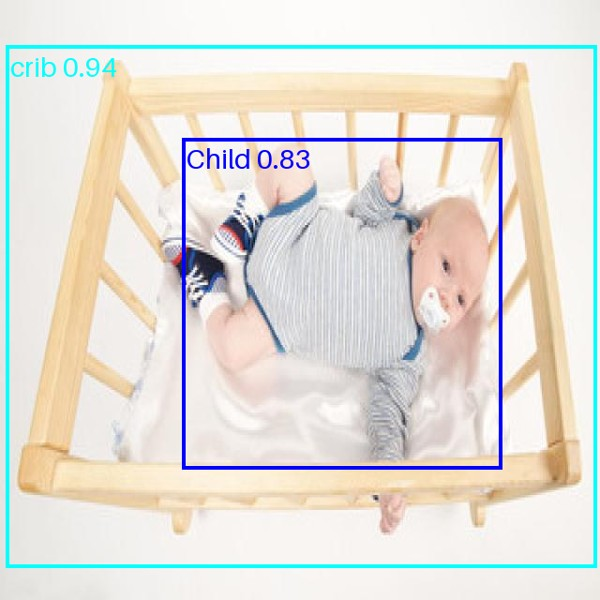

ALERT: ALL CLEAR (0.049 seconds)


In [ ]:
run_demo(test_images[5], 'all_clear')

Detected: crib (0.91)
Detected: Child (0.50)
Detected: blanket (0.71)


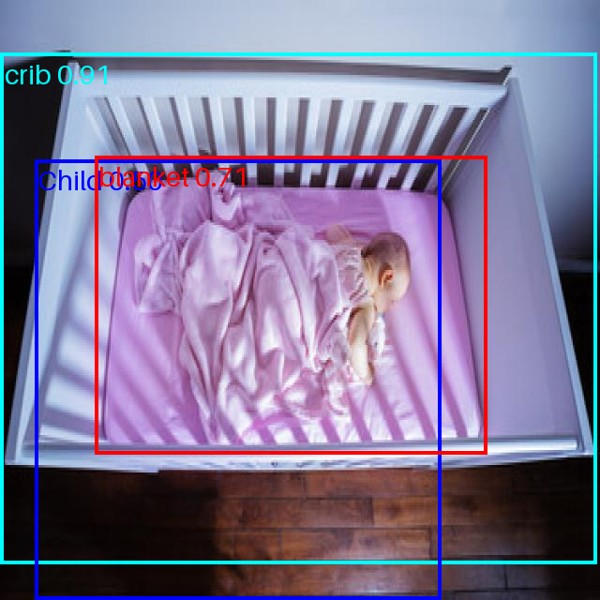

ALERT: HAZARD PRESENT (0.049 seconds)


In [ ]:
run_demo(test_images[9], 'hazard_present')

Detected: crib (0.87)


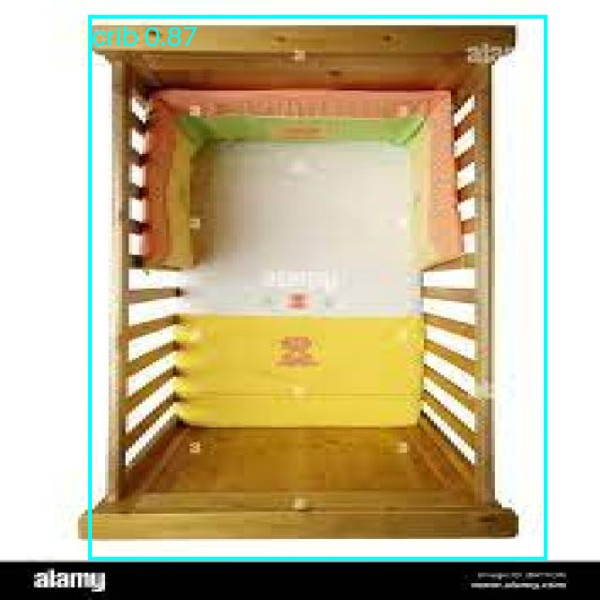

ALERT: NOT VISIBLE (0.050 seconds)


In [ ]:
run_demo(test_images[20], 'not_visible')

Detected: crib (0.79)
Detected: Child (0.87)


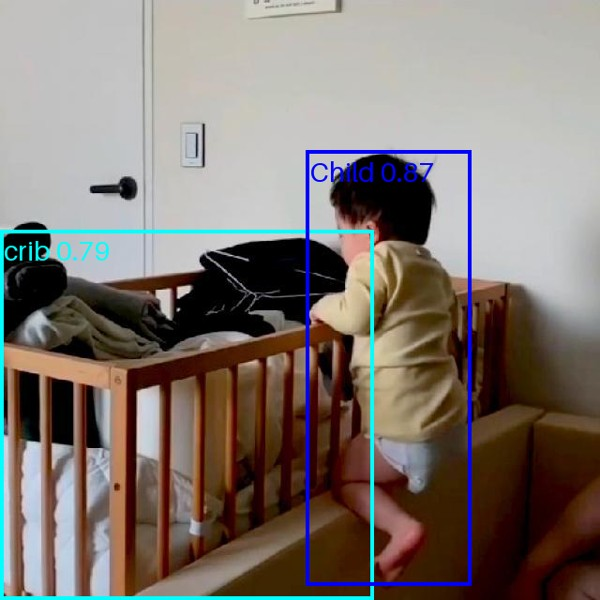

ALERT: LEFT THE CRIB (0.047 seconds)


In [ ]:
run_demo(left_images[5], 'left_the_crib')

Detected: crib (0.81)
Detected: Child (0.85)


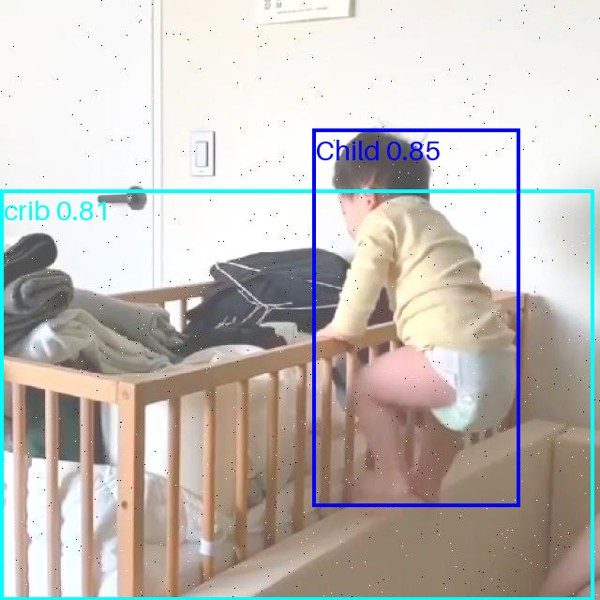

ALERT: ALL CLEAR (0.051 seconds)


In [ ]:
run_demo(left_images[7], 'failure_side_view')

Detected: crib (0.50)
Detected: Child (0.78)
Detected: hard-toy (0.87)


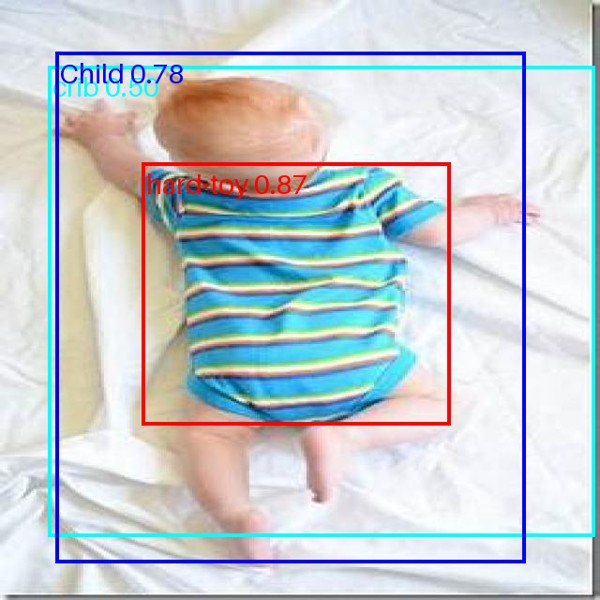

ALERT: HAZARD PRESENT (0.049 seconds)


In [ ]:
run_demo(test_images[13], 'failure_false_crib')

## Results

| Metric | Target | Result |
|---|---|---|
| Alert accuracy on the 24 test images | 85% or more | 70.8% (17 of 24) |
| Time for each image on a T4 GPU | Less than 1 second | 0.034 seconds |
| "Left the crib" on 10 images from a different dataset | No target | 7 of 10 |
| Alert accuracy on the 120 CribHD-C images | No target | 41.7% (50 of 120) |

The system does not meet the 85% target. On CribHD-C it finds the child in 104 of 120 images and the crib in only 76.